THis script cuts a raster file by a multipolygon file

In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import os

In [2]:
# Load the multipolygon shapefile
multipolygon_file = r"Z:\veg_c_storage_rawdata\wb_global_countries\klab_tiles_vcs_bbox.shp"
multipolygon = gpd.read_file(multipolygon_file)

In [ ]:
"""Take the folders in case there is more than one folder"""
# main_path = r"Z:\veg_c_storage_rawdata\testing\to_merge"
main_path = r"Z:\veg_c_storage_rawdata\testing\to_merge"
os.chdir(main_path)
Folder_list = [] #f for f in os.listdir(path) if os.isfile(mypath,f)
for file in os.listdir(main_path): # [1:]
    if os.path.isdir(file):
        if file not in Folder_list:
            Folder_list.append(os.path.join(main_path, file).replace("\\","/"))
    else:
        pass

print(Folder_list[:])

In [3]:
"""In case there is only one folder"""
# main_path = r"C:/Users/admin/Downloads/drive-download-20230605T205149Z-001"
main_path = r"Z:\veg_c_storage_rawdata\testing\to_merge_2\2018_1"
os.chdir(main_path)
Folder_list = [main_path]
print(Folder_list[:])

['Z:\\veg_c_storage_rawdata\\testing\\to_merge_2\\2018_1']


In [4]:
"""check if it takes all files"""
for folder in Folder_list[:]: #[:]
    File_list = [] #f for f in os.listdir(path) if os.isfile(mypath,f)
    for file in os.listdir(folder):
        if file.endswith(".tiff") or file.endswith(".tif"):
            if file not in File_list:
                File_list.append(os.path.join(folder, file).replace("\\","/"))
print(File_list)

['Z:/veg_c_storage_rawdata/testing/to_merge_2/2018_1/vcs_2018_global_300m.tif']


In [5]:
# Iterate over each polygon in the multipolygon
for folder in Folder_list[:]:
    for file in os.listdir(folder):
        # we get the path with the name
        data_path = os.path.join(folder, file).replace("\\","/")
        raster = rasterio.open(data_path)
        for idx, polygon in multipolygon.iterrows(): # .loc[0:1]
            # Get the value from the "tile_index" column
            tile_index = polygon["tile_index"]
            
            # Mask the raster with the polygon geometry
            masked_image, transformed_affine = mask(raster, [polygon.geometry], crop=True)
            
            out_meta = raster.meta

            out_meta.update({"driver": "GTiff",
                            "height": masked_image.shape[1],
                            "width": masked_image.shape[2],
                            "transform": transformed_affine,
                            "compress":"deflate",
                            "tiled":True})

            # Create a new raster file with the masked image
            masked_raster_file = folder + r"\tile_{}.tiff".format(tile_index)
            with rasterio.open(masked_raster_file, "w", **out_meta) as dst:
                dst.write(masked_image)

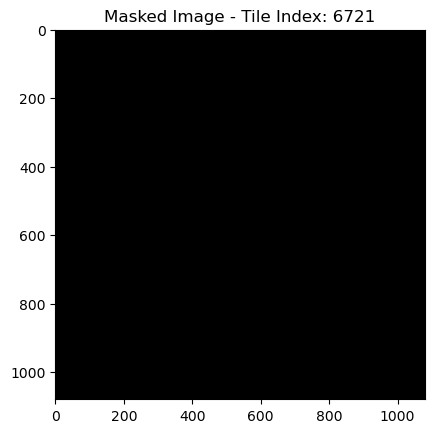

In [5]:
# Plot the masked image for preview
plt.imshow(masked_image[0], cmap='gray')
plt.title(f"Masked Image - Tile Index: {tile_index}")
plt.show()